In [690]:
import json
from typing import Dict, Any, Optional
import time
import os
import torch
import numpy as np
from PIL import Image
import noisereduce as nr
import sounddevice as sd
import soundfile as sf
import librosa
import mediapipe as mp
import cv2
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoImageProcessor,
    AutoModelForImageClassification,
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
)
import textwrap
from concurrent.futures import ThreadPoolExecutor
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.llms import Ollama

In [622]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [669]:
TEXT_MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
IMAGE_MODEL_NAME = "dima806/facial_emotions_image_detection"
VOICE_MODEL_NAME = "superb/wav2vec2-base-superb-er"
OLLAMA_MODEL_NAME="llama3.2:3b"
BASE_THRESHOLD = 0.25
DISAGREEMENT_THRESHOLD=0.7
MIN_CONFIDENCE_THRESHOLD = 0.3

# Load Text, Image Audio model from Hugging Face
 - For Text analysys, cardiffnlp/twitter-roberta-base-sentiment-latest
 - For Image analysys, trpakov/vit-face-expression
 - For Audio analysys, ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition

In [624]:
# Text Model (twitter-roberta-base-sentiment-latest)
text_tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)
text_model = AutoModelForSequenceClassification.from_pretrained(TEXT_MODEL_NAME).to(device)
text_model.eval()
print("Loaded text model:", TEXT_MODEL_NAME)

Loading weights: 100%|██████████| 201/201 [00:01<00:00, 187.60it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded text model: cardiffnlp/twitter-roberta-base-sentiment-latest


In [625]:
image_processor = AutoImageProcessor.from_pretrained(IMAGE_MODEL_NAME)
image_model = AutoModelForImageClassification.from_pretrained(IMAGE_MODEL_NAME).to(device)
image_model.eval()
print("Loaded image model:", IMAGE_MODEL_NAME)

Loading weights: 100%|██████████| 200/200 [00:01<00:00, 177.74it/s, Materializing param=vit.layernorm.weight]                                 


Loaded image model: dima806/facial_emotions_image_detection


In [626]:
voice_extractor = AutoFeatureExtractor.from_pretrained(VOICE_MODEL_NAME)
voice_model = AutoModelForAudioClassification.from_pretrained(VOICE_MODEL_NAME).to(device)
voice_model.eval()
print("Loaded voice model:", VOICE_MODEL_NAME)
print("Model Labels:", voice_model.config.id2label)

Loading weights: 100%|██████████| 216/216 [00:01<00:00, 157.04it/s, Materializing param=wav2vec2.masked_spec_embed]                                            


Loaded voice model: superb/wav2vec2-base-superb-er
Model Labels: {0: 'neu', 1: 'hap', 2: 'ang', 3: 'sad'}


In [679]:
llm = Ollama(model=OLLAMA_MODEL_NAME, num_predict=100,num_thread= 4, temperature=0.1, stop=["<|eot_id|>", "---"])
parser = StrOutputParser()

# Different models output different types of emotional labels.
  Image model and voice model output emotions like:
   - happy
   - sad
   - angry
   - fear
   - disgust
   - surprise
  #### But final system needs only three categories:
   - positive
   - neutral
   - negative
  #### So created a dictionary to acts like a translator.


In [ ]:
emotion_to_sentiment = {
    "hap": "positive",
    "neu": "neutral",
    "ang": "negative",
    "sad": "negative",
    "happy": "positive",
    "surprise": "positive",
    "neutral": "neutral",
    "sad": "negative",
    "angry": "negative",
    "fear": "negative",
    "disgust": "negative",
}

sentiment_score = {
    "positive": 1,
    "neutral": 0,
    "negative": -1,
}


#Different models sometimes return labels in different formats:
    # "Happy"
    # "HAPPY"
    # "happy "
    # "surprised_"
    # "fear_full"
# This function cleans and standardizes them so your system doesn’t break.

def normalize_label(label: str) -> str:
    return label.lower().strip().replace("_", "")

# This function prints results in a clean, readable format.
def pretty(obj: Any) -> None:
    # This helper handles NumPy types and nested dictionaries
    def convert(item):
        if isinstance(item, np.integer): return int(item)
        if isinstance(item, np.floating): return float(item)
        if isinstance(item, np.ndarray): return item.tolist()
        if isinstance(item, np.bool_): return bool(item) 
        return item

    # Use a recursive approach or just cast the specific troublesome keys
    # But for a quick fix, just standardizing the fused dictionary is best:
    print(json.dumps(obj, indent=2, default=convert))




def timed(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        duration = time.time() - start
        print(f"{func.__name__} took {duration:.4f} seconds")
        return result
    return wrapper

# This function takes a piece of text (like a sentence or message) and figures out whether the emotion behind it is:
- positive
- neutral
- negative
# It uses a pre‑trained AI language model (RoBERTa) to do this.
# Then it returns:
- the predicted sentiment
- the confidence score
- the full probability breakdown


- The text is converted into a format the AI model understands.
- This process is called tokenization.
- truncation=True ensures long text is safely shortened.
- .to(device) sends it to GPU if available (faster), otherwise CPU.
- inference_mode() tells the model: “We are only predicting, not training.”
- The model processes the text and produces raw scores.
- softmax converts those raw scores into probabilities.
- .cpu().numpy()[0] converts the result into a normal Python‑friendly format.
- argmax finds the index of the highest score.
- That index is used to pick the correct label.
# returns:
- sentiment → the final label (positive/neutral/negative)
- raw_sentiment → same as above (kept for consistency)
- scores → all three probabilities
- confidence → how sure the model is about the chosen labe



In [629]:
@timed
def analyze_text_sentiment(text: str) -> Dict[str, Any]:
    inputs = text_tokenizer(text, return_tensors="pt", truncation=True).to(device)

    with torch.inference_mode():
        outputs = text_model(**inputs)
        scores = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

    labels = ["negative", "neutral", "positive"]
    idx = int(np.argmax(scores))
    sentiment = labels[idx]

    return {
        "sentiment": sentiment,
        "raw_sentiment": sentiment,
        "scores": dict(zip(labels, scores.tolist())),
        "confidence": float(scores[idx]),
    }

In [630]:
# Load the built-in face detector
# https://unsplash.com/
os.makedirs("debug_logs", exist_ok=True)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
@timed
def analyze_image_sentiment(image: Image.Image) -> Dict[str, Any]:
    # 1. Convert PIL to OpenCV format (BGR)
    # This is necessary because models need a clear look at the face features
    img_array = np.array(image.convert('RGB'))
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    
    # 2. Detect faces
    # This ignores the background and the shirt text
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
    face_found = False
    final_image = image
    if len(faces) > 0:
        face_found = True
        # Sort by area to get the largest face (closest to camera)
        (x, y, w, h) = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
        
        # Add 20% padding to ensure we don't cut off chin/forehead
        pad_w, pad_h = int(w * 0.2), int(h * 0.2)
        left = max(0, x - pad_w)
        top = max(0, y - pad_h)
        right = min(img_array.shape[1], x + w + pad_w)
        bottom = min(img_array.shape[0], y + h + pad_h)
        
        # Crop the PIL image
        final_image = image.crop((left, top, right, bottom))
        debug_path = f"debug_logs/last_crop_{int(time.time())}.jpg"
        final_image.save(debug_path)
        # print("Face detected and isolated. Background/Shirt ignored.")

    # 

    # 3. Standard model inference on the CROPPED face
    inputs = image_processor(images=final_image, return_tensors="pt").to(device)

    with torch.inference_mode():
        outputs = image_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

    id2label = image_model.config.id2label
    labels = [normalize_label(id2label[i]) for i in range(len(probs))]

    idx = int(np.argmax(probs))
    norm_label = labels[idx]
    
    return {
        "sentiment": emotion_to_sentiment.get(norm_label, "neutral"),
        "raw_emotion": id2label[idx],
        "scores": dict(zip(labels, probs.tolist())),
        "confidence": float(probs[idx]),
        "face_detected": face_found
    }

In [631]:
test_img = Image.open("sad_face.jpg")  
image_analysis= analyze_image_sentiment(test_img)
image_analysis

analyze_image_sentiment took 2.2775 seconds


{'sentiment': 'negative',
 'raw_emotion': 'angry',
 'scores': {'sad': 0.1393079310655594,
  'disgust': 0.01884978450834751,
  'angry': 0.358429491519928,
  'neutral': 0.024988606572151184,
  'fear': 0.30611151456832886,
  'surprise': 0.03254257142543793,
  'happy': 0.11976996809244156},
 'confidence': 0.358429491519928,
 'face_detected': True}

In [632]:
@timed
def analyze_voice_sentiment(audio_path: str) -> Dict[str, Any]:
    # 1. Load at 16k (Required for Wav2Vec2)
    audio, sr = librosa.load(audio_path, sr=16000)

    # 2. Moderate Trim
    # We lowered top_db to 35 to ensure we don't cut off the 'energy' peaks
    audio, _ = librosa.effects.trim(audio, top_db=35)

    # 3. Dynamic Gain Normalization
    # We normalize and then apply a 1.2x boost. 
    # This emphasizes the 'arousal' (volume peaks) that indicate excitement/joy.
    if np.max(np.abs(audio)) > 0:
        audio = audio / (np.max(np.abs(audio)) + 1e-9)
        audio = audio * 1.2 

    # 4. Feature Extraction
    inputs = voice_extractor(
        audio,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True,
    ).to(device)

    with torch.inference_mode():
        outputs = voice_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

    id2label = voice_model.config.id2label 
    
    # 5. Strategic Mapping
    idx = int(np.argmax(probs))
    raw_label = id2label[idx]  # e.g., 'neu'
    
    # Create an explicit scores dictionary that matches your fusion logic keys
    # This ensures 'hap' probability is passed as 'positive'
    scores_dict = {
        "neutral": float(probs[0]),   # 'neu'
        "positive": float(probs[1]),  # 'hap'
        "negative": float(probs[2]) + float(probs[3]) # 'ang' + 'sad'
    }

    # Decide the sentiment
    # If neutral is only slightly leading, we let the fusion weights decide later
    mapped_sentiment = emotion_to_sentiment.get(raw_label, "neutral")

    return {
        "sentiment": mapped_sentiment,
        "raw_emotion": raw_label,
        "scores": scores_dict,
        "confidence": float(probs[idx]),
    }

In [573]:
#To record a fresh sample:
#• 	“This is amazing, I love it!”  “I can’t believe how great this is!”
test_audio_path = record_audio("voice.wav", duration=4)

Recording... Speak now.
Recording complete. Saved to voice.wav
record_audio took 4.2559 seconds


In [579]:
from IPython.display import Audio
Audio("voice.wav")

In [582]:
result = analyze_voice_sentiment("voice.wav")

# Load audio properly
audio, sr = librosa.load("voice.wav", sr=16000)

# Correct duration calculation
duration = len(audio) / sr
print("Duration:", duration, "seconds")

print(result)



analyze_voice_sentiment took 0.6002 seconds
Duration: 4.0 seconds
{'sentiment': 'neutral', 'raw_emotion': 'neu', 'scores': {'neutral': 0.6624360084533691, 'positive': 0.24048589169979095, 'negative': 0.09707815945148468}, 'confidence': 0.6624360084533691}


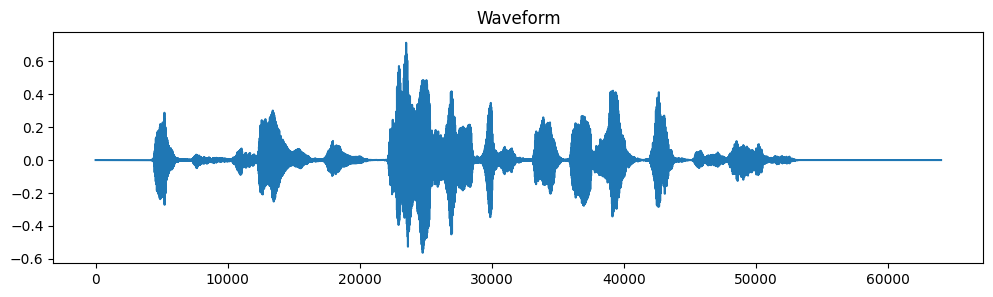

In [578]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,3))
plt.plot(audio)
plt.title("Waveform")
plt.show()

# This function takes the emotional results from:
 - text
 - image
 - voice
# and combines them into one final sentiment (positive, neutral, or negative).
# It does this by:
 - Looking at how confident each modality is
 -	Giving more weight to the stronger signals
 - 	Blending them into a single emotional score
 - 	Checking if the modalities disagree
 - 	Producing the final sentiment
# It’s like having three friends give their opinion — but listening more to the friend who is most sure.

In [ ]:
@timed
def fuse_logic(
    text_res: Dict[str, Any],
    image_res: Dict[str, Any],
    voice_res: Optional[Dict[str, Any]] = None,
) -> Dict[str, Any]:
    
    # 1. THE HEURISTIC BRIDGE: Handle "Hidden" Happiness
    # If text is extremely positive (>0.9) and voice is neutral, 
    # but the voice model actually detected some happy signal (the 0.22 you saw earlier)
    if voice_res and text_res["sentiment"] == "positive" and text_res["confidence"] > 0.9:
        if voice_res["sentiment"] == "neutral" and voice_res["scores"].get("positive", 0) > 0.15:
            # We "nudge" the voice to positive because the model is being too shy
            voice_res["sentiment"] = "positive"
            # We lower the voice confidence slightly so it doesn't overpower, 
            # but it no longer pulls the average to 0.
            voice_res["confidence"] = max(voice_res["confidence"], 0.5) 

    # 2. Prepare Data for Weighted Average
    data = []

    # Only add text if it's reliable
    if text_res["confidence"] > MIN_CONFIDENCE_THRESHOLD:
        data.append((sentiment_score[text_res["sentiment"]], text_res["confidence"]))

    # Only add image if a face was actually detected AND confidence is decent
    if image_res["face_detected"] and image_res["confidence"] > MIN_CONFIDENCE_THRESHOLD:
        data.append((sentiment_score[image_res["sentiment"]], image_res["confidence"]))


    if voice_res:
        data.append((sentiment_score[voice_res["sentiment"]], voice_res["confidence"]))

    vals, confs = zip(*data)
    confs = np.array(confs)
    vals = np.array(vals)

    # 3. Calculate Weights
    total_conf = np.sum(confs)
    weights = confs / total_conf if total_conf > 0 else np.ones_like(confs) / len(confs)
    
    # 4. Final Sentiment Value Calculation
    fused_val = np.dot(vals, weights)
    


  
    avg_conf = np.mean(confs)
    adaptive_threshold = BASE_THRESHOLD * (1 - avg_conf)

    if fused_val > adaptive_threshold:
        final_label = "positive"
    elif fused_val < -adaptive_threshold:
        final_label = "negative"
    else:
        final_label = "neutral"


    signal_spread = np.std(vals)
    is_conflict = signal_spread > DISAGREEMENT_THRESHOLD

    is_potential_sarcasm = (
    text_res["sentiment"] == "positive" and 
    (image_res["sentiment"] == "negative" or (voice_res and voice_res["sentiment"] == "negative"))
        )

    return {
        "final_sentiment": final_label,
        "fused_score": round(float(fused_val), 3),
        "adaptive_threshold": round(adaptive_threshold, 3),
        "avg_confidence": round(avg_conf, 3),
        "is_conflict": is_conflict,
        "sarcasm_hint":is_potential_sarcasm,
        "spread": round(float(signal_spread), 3),
        "weights": {
            "text_weight": round(weights[0], 3),
            "image_weight": round(weights[1], 3),
            "voice_weight": round(weights[2], 3) if voice_res else 0.0
        },
        "text_data": text_res,
        "image_data": image_res,
        "voice_data": voice_res,
    }

In [686]:
prompt = PromptTemplate.from_template(
    """
    [INST] You are a Multimodal Sentiment Expert.
    DECISION: {final_sentiment}
    - Text: {text_sentiment} (Weight: {text_weight})
    - Face: {image_sentiment} (Weight: {image_weight})
    - Voice: {voice_sentiment} (Weight: {voice_weight})
    - Conflict detected? {is_conflict} | Sarcasm/Stress Hint: {sarcasm_hint}

    TASK: 
    Write exactly 2 sentences explaining why the final decision is {final_sentiment}. 
    Be sure to point out that the user's face looked {image_sentiment} despite their {text_sentiment} words, which indicates sarcasm or emotional suppression.
    Ensure the final sentence is complete and explains the conflict. [/INST]
    """
)


In [635]:
@timed
def record_audio(output_path: str = "voice.wav", duration: int = 4, samplerate: int = 16000) -> str:
    print("Recording... Speak now.")
    audio = sd.rec(int(duration * samplerate), samplerate=samplerate, channels=1)
    sd.wait()
    sf.write(output_path, audio, samplerate)
    print(f"Recording complete. Saved to {output_path}")
    return output_path

In [687]:
EXPLANATION_CACHE = {}

@timed
def explain_multimodal_sentiment(
    text: str,
    image: Image.Image,
    audio_path: Optional[str] = None,
) -> Dict[str, Any]:

    # Run modalities
    #text_res = analyze_text_sentiment(text)
    #image_res = analyze_image_sentiment(image)
    #voice_res = analyze_voice_sentiment(audio_path) if audio_path else None


    with ThreadPoolExecutor() as executor:
        print("Starting parallel analysis...")
        future_text = executor.submit(analyze_text_sentiment, text)
        future_image = executor.submit(analyze_image_sentiment, image)
        future_voice = executor.submit(analyze_voice_sentiment, audio_path) if audio_path else None
        
        text_res = future_text.result()
        image_res = future_image.result()
        voice_res = future_voice.result() if future_voice else None

    # Fuse
    fused = fuse_logic(text_res, image_res, voice_res)

    # Build cache key (small + deterministic)
    cache_key = (
        text,
        text_res["sentiment"],
        image_res["sentiment"],
        voice_res["sentiment"] if voice_res else None,
        fused["fused_score"],
        fused["adaptive_threshold"],
    )

    # Return cached explanation if available
    if cache_key in EXPLANATION_CACHE:
        return {
            "text_result": text_res,
            "image_result": image_res,
            "voice_result": voice_res,
            "fusion_result": fused,
            "explanation": EXPLANATION_CACHE[cache_key],
        }

    # Prepare prompt vars
    prompt_vars = {
        "original_text": text,

        "text_sentiment": text_res["sentiment"],
        "text_conf": round(text_res["confidence"], 2),
        "text_weight": round(fused["weights"]["text_weight"],2),

        "image_sentiment": image_res["sentiment"],
        "image_raw_emotion": image_res["raw_emotion"],
        "image_conf": round(image_res["confidence"], 2),
        "face_detected":"Yes" if image_res["face_detected"] else "No",
        "image_weight": round(fused["weights"]["image_weight"],2),

        "voice_sentiment": voice_res["sentiment"] if voice_res else "N/A",
        "voice_raw_emotion": voice_res["raw_emotion"] if voice_res else "N/A",
        "voice_conf": round(voice_res["confidence"], 2) if voice_res else 0.0,
        "voice_weight": round(fused["weights"]["voice_weight"],2),

        "final_sentiment": fused["final_sentiment"].upper(),
        "fused_score": round(fused["fused_score"],2),
        "adaptive_threshold": round(fused["adaptive_threshold"],2),
        "avg_confidence": round(fused["avg_confidence"],2),
        "spread": round(fused["spread"],2),
        "is_conflict": "YES" if fused["is_conflict"] else "No",
        "sarcasm_hint": "YES" if fused["sarcasm_hint"] else "No",
    }

    formatted = prompt.format(**prompt_vars)

    # -----------------------------
    # STREAMING LLM CALL
    # -----------------------------
    start = time.perf_counter()
    streamed_output = ""

    print("\n--- Sending to LLM ---")
    for key, value in prompt_vars.items():
        print(f"Placeholder {{{key}}}: {value}")
    print("----------------------\n")

    for chunk in llm.stream(formatted):
        streamed_output += chunk  # accumulate tokens

    print("LLM time:", time.perf_counter() - start)

    # Parse explanation
    explanation = parser.parse(streamed_output)

    # Cache it
    EXPLANATION_CACHE[cache_key] = explanation

    return {
        "text_result": text_res,
        "image_result": image_res,
        "voice_result": voice_res,
        "fusion_result": fused,
        "explanation": explanation,
    }

In [683]:
test_img = Image.open("sad_face.jpg")  # ensure this exists
test_text = "I love this place, but I'm feeling a bit overwhelmed!"
test_audio_path = "voice.wav"  # or any existing wav file, or record one below

In [522]:
#To record a fresh sample:
test_audio_path = record_audio("voice.wav", duration=4)

Recording... Speak now.
Recording complete. Saved to voice.wav
record_audio took 4.3662 seconds


In [688]:
result = explain_multimodal_sentiment(test_text, test_img, audio_path=test_audio_path)
print("\n--- FUSION RESULT ---")
pretty(result["fusion_result"])

Starting parallel analysis...
analyze_text_sentiment took 1.1290 seconds
analyze_voice_sentiment took 1.6243 seconds
analyze_image_sentiment took 1.8246 seconds
fuse_logic took 0.0017 seconds

--- Sending to LLM ---
Placeholder {original_text}: I love this place, but I'm feeling a bit overwhelmed!
Placeholder {text_sentiment}: positive
Placeholder {text_conf}: 0.74
Placeholder {text_weight}: 0.42
Placeholder {image_sentiment}: negative
Placeholder {image_raw_emotion}: angry
Placeholder {image_conf}: 0.36
Placeholder {face_detected}: Yes
Placeholder {image_weight}: 0.2
Placeholder {voice_sentiment}: neutral
Placeholder {voice_raw_emotion}: neu
Placeholder {voice_conf}: 0.66
Placeholder {voice_weight}: 0.38
Placeholder {final_sentiment}: POSITIVE
Placeholder {fused_score}: 0.22
Placeholder {adaptive_threshold}: 0.1
Placeholder {avg_confidence}: 0.59
Placeholder {spread}: 0.82
Placeholder {is_conflict}: YES
Placeholder {sarcasm_hint}: YES
----------------------

LLM time: 13.6291592998895

In [ ]:
print("\n--- FINAL EXPLANATION ---")
wrapper = textwrap.TextWrapper(width=80, break_long_words=False)
formatted_explanation = wrapper.fill(result["explanation"])
print(formatted_explanation)


--- FINAL EXPLANATION ---
The final decision of POSITIVE is based on the majority weight of the text
analysis, which indicates a strong sentiment of positivity despite some
potential emotional undertones. However, the detected conflict and hint of
sarcasm/stress in the user's face suggests that their negative facial expression
may be masking their true emotions, indicating a more complex emotional state
than initially conveyed by their words.


In [487]:
from datasets import load_dataset, Audio

ds = load_dataset("mteb/meld")

# Disable audio decoding
ds = ds.cast_column("audio", Audio(decode=False))

# Remove video column to avoid video decoding
ds = ds.remove_columns(["video"])

In [488]:

sample = ds["test"][0]
print(sample)


{'video_id': 'dia0_utt0.mp4', 'audio': {'bytes': b'RIFF\xf0\x1a\x01\x00WAVEfmt \x10\x00\x00\x00\x01\x00\x01\x00\x80>\x00\x00\x00}\x00\x00\x02\x00\x10\x00LIST\x1a\x00\x00\x00INFOISFT\x0e\x00\x00\x00Lavf58.76.100\x00data\xaa\x1a\x01\x00X\x01\xeb\x01\xc4\x01\xf4\x00\x11\x00>\xffc\xff\x9a\x00\xbd\x01\xc3\x01v\x01C\x01s\x01\xeb\x00\xb5\xff>\xffn\xff\xbb\xff\xe4\xff\xc4\xff\x8e\xff6\xff\xf2\xfe\xf6\xfe\xb1\xfeX\xfe\xfb\xfd&\xfe\xf8\xfeN\xff\x82\xff\xdf\xff\x0e\x00\xd9\xff\xb2\xff\xa8\xff\xa6\xff\x11\x00\xba\x00\xe1\x00\'\x01k\x01\xb9\x01,\x02*\x02i\x01\x9a\x00\x12\x00\xf6\xffA\x007\x00\xaf\xffv\xff\x95\xff\xd6\xffU\x00x\x00\xd1\xff_\xff\xd5\xff2\x00\xb1\xff\x12\xff"\xff\xa0\xff\xa8\xffz\xff\xaa\xff\x94\xff\xa5\xff\xc0\xff\xa2\xff\x8f\xff\xfb\xff\x9e\x00\xe4\x00\xaf\x00I\x00K\x00\x96\x00\xe7\xff\xfd\xfe%\xff\xd4\xff\x11\x00\xfc\xff\xea\xff\xc1\xff\xe4\xffV\x00t\x00\x14\x00\xcc\xff\xeb\xff\xec\xff0\xff\x99\xfe\xc7\xfe\xc1\xffe\x00k\x00\x9f\x00\xe7\x00\xaf\x00&\x00\x0b\x00\xee\xff\xd6\xff\xfc\x

In [498]:
import soundfile as sf
import numpy as np

sample = ds["test"][0]

audio_bytes = sample["audio"]["bytes"]

# Convert bytes → numpy array
import io
import soundfile as sf

data, sr = sf.read(io.BytesIO(audio_bytes))

# Save to a real WAV file
sf.write("temp.wav", data, sr)

print("Saved:", "temp.wav")

Saved: temp.wav


## MELD_EMOTION_MAP = {
    0: "neutral",
    1: "surprise",
    2: "fear",
    3: "sadness",
    4: "joy",
    5: "disgust",
    6: "anger"
}


In [499]:
from IPython.display import Audio
Audio("temp.wav")




In [501]:
MELD_EMOTION_MAP = {
    0: "neutral",
    1: "surprise",
    2: "fear",
    3: "sadness",
    4: "joy",
    5: "disgust",
    6: "anger"
}

true_emotion = MELD_EMOTION_MAP[sample["emotion"]]
print("Ground truth:", true_emotion)


Ground truth: anger
